In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ====================== LOADING DATA ======================

file_path = 'players_data-2024_2025.csv'

try:
    df = pd.read_csv(file_path)
    print(f" Dataset loaded! Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("Error: File not found. Make sure you are in the correct folder.")

 Dataset loaded! Shape: (2854, 267)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ====================== DATA SCHEMA ======================

print("=== Data Columns and Types ===\n")

info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count()
})

display(info.head(20))

print("\nThis dataset has many columns with detailed player stats.")

=== Data Columns and Types ===



,Column,Data Type,Non-Null Count
Rk,Rk,int64,2854
Player,Player,object,2854
Nation,Nation,object,2847
Pos,Pos,object,2854
Squad,Squad,object,2854
Comp,Comp,object,2854
Age,Age,float64,2846
Born,Born,float64,2846
MP,MP,int64,2854
Starts,Starts,int64,2854



This dataset has many columns with detailed player stats.


In [4]:
# ====================== DESCRIPTIVE STATISTICS ======================

cols = ['Age', 'MP', 'Starts', 'Min', 'Gls', 'Ast', 'xG', 'Rating']
available_cols = [col for col in cols if col in df.columns]

print("Basic Descriptive Statistics:")
print(df[available_cols].describe().round(2))

print("\nExtra Metrics:")
for col in ['Gls', 'Ast', 'xG']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Mean: {df[col].mean():.2f}")
        print(f"  Variance: {df[col].var():.2f}")
        print(f"  Std Dev: {df[col].std():.2f}")

Basic Descriptive Statistics:
           Age       MP   Starts      Min      Gls      Ast       xG
count  2846.00  2854.00  2854.00  2854.00  2854.00  2854.00  2854.00
mean     25.02    19.01    13.50  1211.53     1.68     1.20     1.71
std       4.49    11.50    11.32   965.19     3.15     1.95     2.82
min      15.00     1.00     0.00     1.00     0.00     0.00     0.00
25%      22.00     9.00     3.00   317.25     0.00     0.00     0.10
50%      25.00    20.00    11.00  1052.50     0.00     0.00     0.70
75%      28.00    30.00    23.00  1996.75     2.00     2.00     2.10
max      41.00    38.00    38.00  3420.00    31.00    18.00    27.10

Extra Metrics:

Gls:
  Mean: 1.68
  Variance: 9.94
  Std Dev: 3.15

Ast:
  Mean: 1.20
  Variance: 3.79
  Std Dev: 1.95

xG:
  Mean: 1.71
  Variance: 7.94
  Std Dev: 2.82


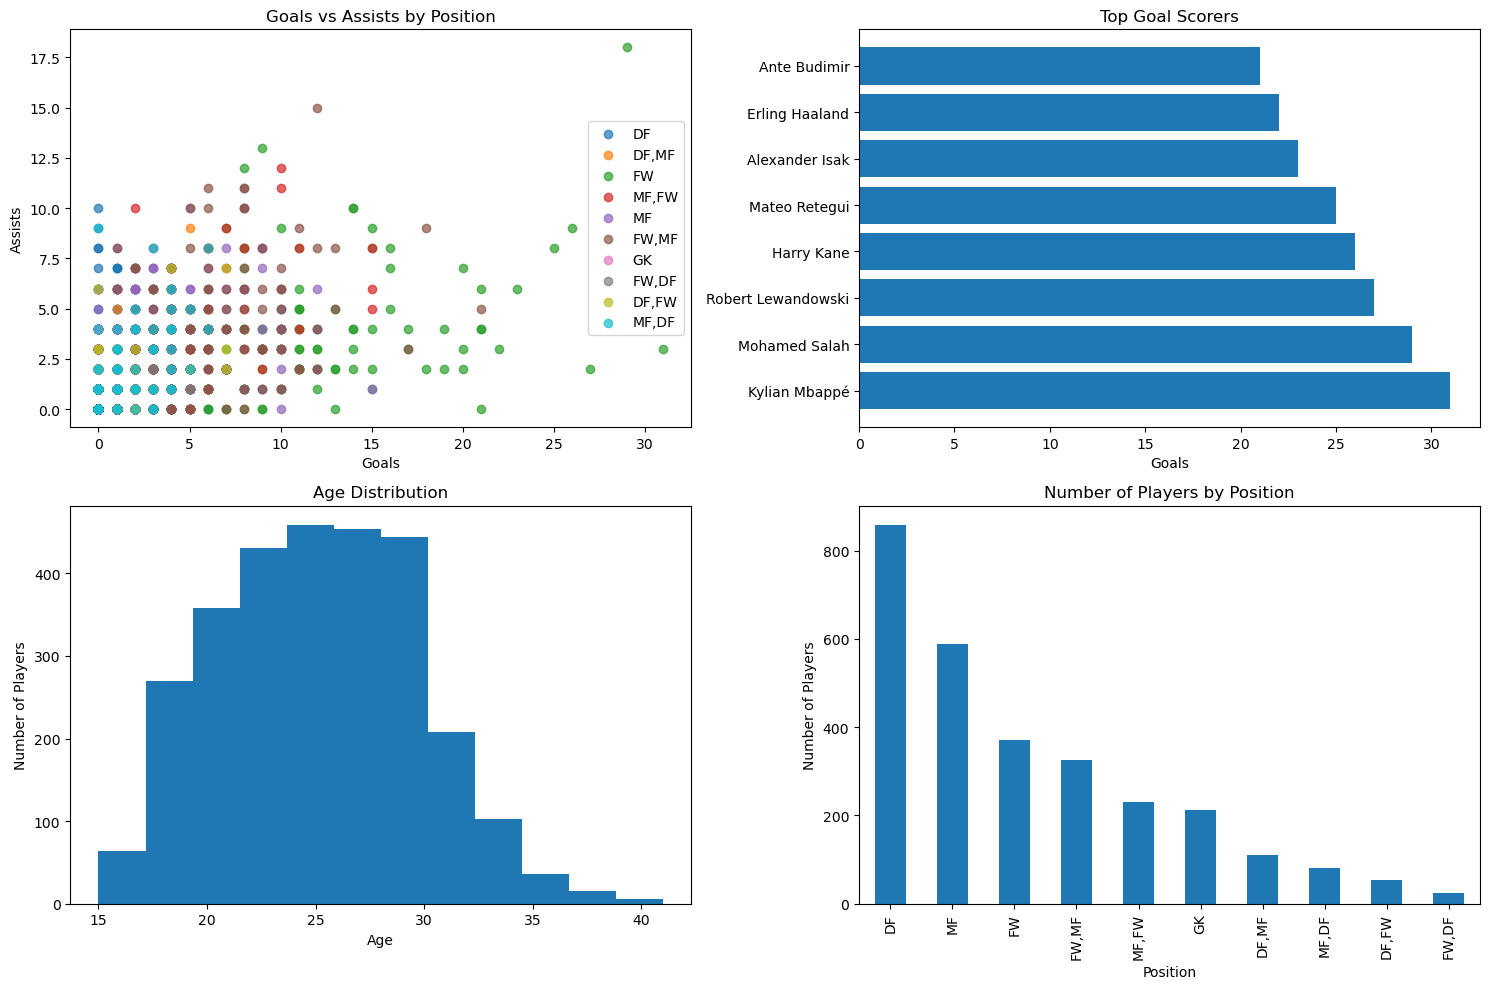


Top Goal Scorers:


,Player,Squad,Pos,Gls,Ast
1691,Kylian Mbappé,Real Madrid,FW,31,3
2304,Mohamed Salah,Liverpool,FW,29,18
1483,Robert Lewandowski,Barcelona,FW,27,2
1317,Harry Kane,Bayern Munich,FW,26,9
2201,Mateo Retegui,Atalanta,FW,25,8
1219,Alexander Isak,Newcastle Utd,FW,23,6
1109,Erling Haaland,Manchester City,FW,22,3


In [7]:
# ====================== VISUALIZATIONS ======================

plt.figure(figsize=(15, 10))

# 1. Goals vs Assists by Position
plt.subplot(2, 2, 1)

positions = df['Pos'].unique()

for pos in positions:
    subset = df[df['Pos'] == pos]
    plt.scatter(subset['Gls'], subset['Ast'], label=pos, alpha=0.7)

plt.xlabel("Goals")
plt.ylabel("Assists")
plt.title("Goals vs Assists by Position")
plt.legend()

# 2. Top Goal Scorers
plt.subplot(2, 2, 2)

top_scorers = df.nlargest(8, 'Gls')

plt.barh(top_scorers['Player'], top_scorers['Gls'])
plt.xlabel("Goals")
plt.title("Top Goal Scorers")

# 3. Age Distribution
plt.subplot(2, 2, 3)

plt.hist(df['Age'], bins=12)
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.title("Age Distribution")

# 4. Number of Players by Position
plt.subplot(2, 2, 4)

df['Pos'].value_counts().plot(kind='bar')
plt.title("Number of Players by Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

print("\nTop Goal Scorers:")
top = df.nlargest(7, 'Gls')[['Player', 'Squad', 'Pos', 'Gls', 'Ast']]
display(top)